In [1]:
import numpy as np
import pandas as pd

In [11]:
gauge_pre=np.load('guage_pre_all.npy')
df_posi=pd.read_csv('df_posi_02—10.csv')


In [3]:
gauge_sum=np.nansum(gauge_pre,axis=0)

In [ ]:
fenbian=0.2
p=int(7/fenbian)
q=int(11/fenbian)
num=np.zeros((p,q))
for i in range(len(df_posi["lons"])):
    x=int((df_posi["lons"][i]-111)/fenbian)
    y=int((df_posi["lats"][i]-30)/fenbian)
    num[y,x]=num[y,x]+1

In [20]:
num[num>=4].shape#5

(158,)

In [6]:
#随机取10次，100次，500次
#最大站点数目取15，有5个区域

df_filtered=df_posi[df_posi['num']>=41]
groups = df_filtered.groupby(['indexi', 'indexj'])

In [10]:
df_filtered.shape

(41, 5)

In [7]:
groups.groups

{(1, 45): [480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520]}

In [9]:
Rain={}
df_filtered

,indexi,indexj,lons,lats,num
480,1,45,120.0858,30.2656,43
481,1,45,120.1558,30.3011,43
482,1,45,120.0856,30.2964,43
483,1,45,120.1153,30.2753,43
484,1,45,120.0019,30.2478,43
485,1,45,120.1561,30.2436,43
486,1,45,120.0778,30.2031,43
487,1,45,120.0817,30.3089,43
488,1,45,120.1772,30.3419,43
489,1,45,120.1986,30.2553,43


In [46]:
suiji=10
n_gauge=41
samples={}
rain={}
for n in range(n_gauge):#几个站点
    n=n+1
    rain[n]=[]
    for i in range(suiji):#随机几次
        samples[i]=[]
        for name, group in groups:#所有的格子
            # print(f"Group: {name}")
            samples[i] = np.append(samples[i],np.random.choice(group.index, n, replace=False))
        rain[n]=np.append(rain[n],np.nanmean(gauge_sum[(samples[i]).astype(int)]))

Rain[0]=rain

suiji=100
samples={}
rain={}
for n in range(n_gauge):
    n=n+1
    rain[n]=[]
    for i in range(suiji):
        samples[i]=[]
        for name, group in groups:
            # print(f"Group: {name}")
            samples[i] = np.append(samples[i],np.random.choice(group.index, n, replace=False))
        rain[n]=np.append(rain[n],np.nanmean(gauge_sum[(samples[i]).astype(int)]))

Rain[1]=rain


# suiji=500
# samples={}
# rain={}
# for n in range(n_gauge):
#     n=n+1
#     rain[n]=[]
#     for i in range(suiji):
#         samples[i]=[]
#         for name, group in groups:
#             # print(f"Group: {name}")
#             samples[i] = np.append(samples[i],np.random.choice(group.index, n, replace=False))
#         rain[n]=np.append(rain[n],np.nanmean(gauge_sum[(samples[i]).astype(int)]))

# Rain[2]=rain
    # print()

In [47]:
# #所有筛选出来站点的值
mean_pre=np.nanmean(gauge_sum[df_filtered.index])

In [48]:
mean_pre

np.float64(7494.765441463414)

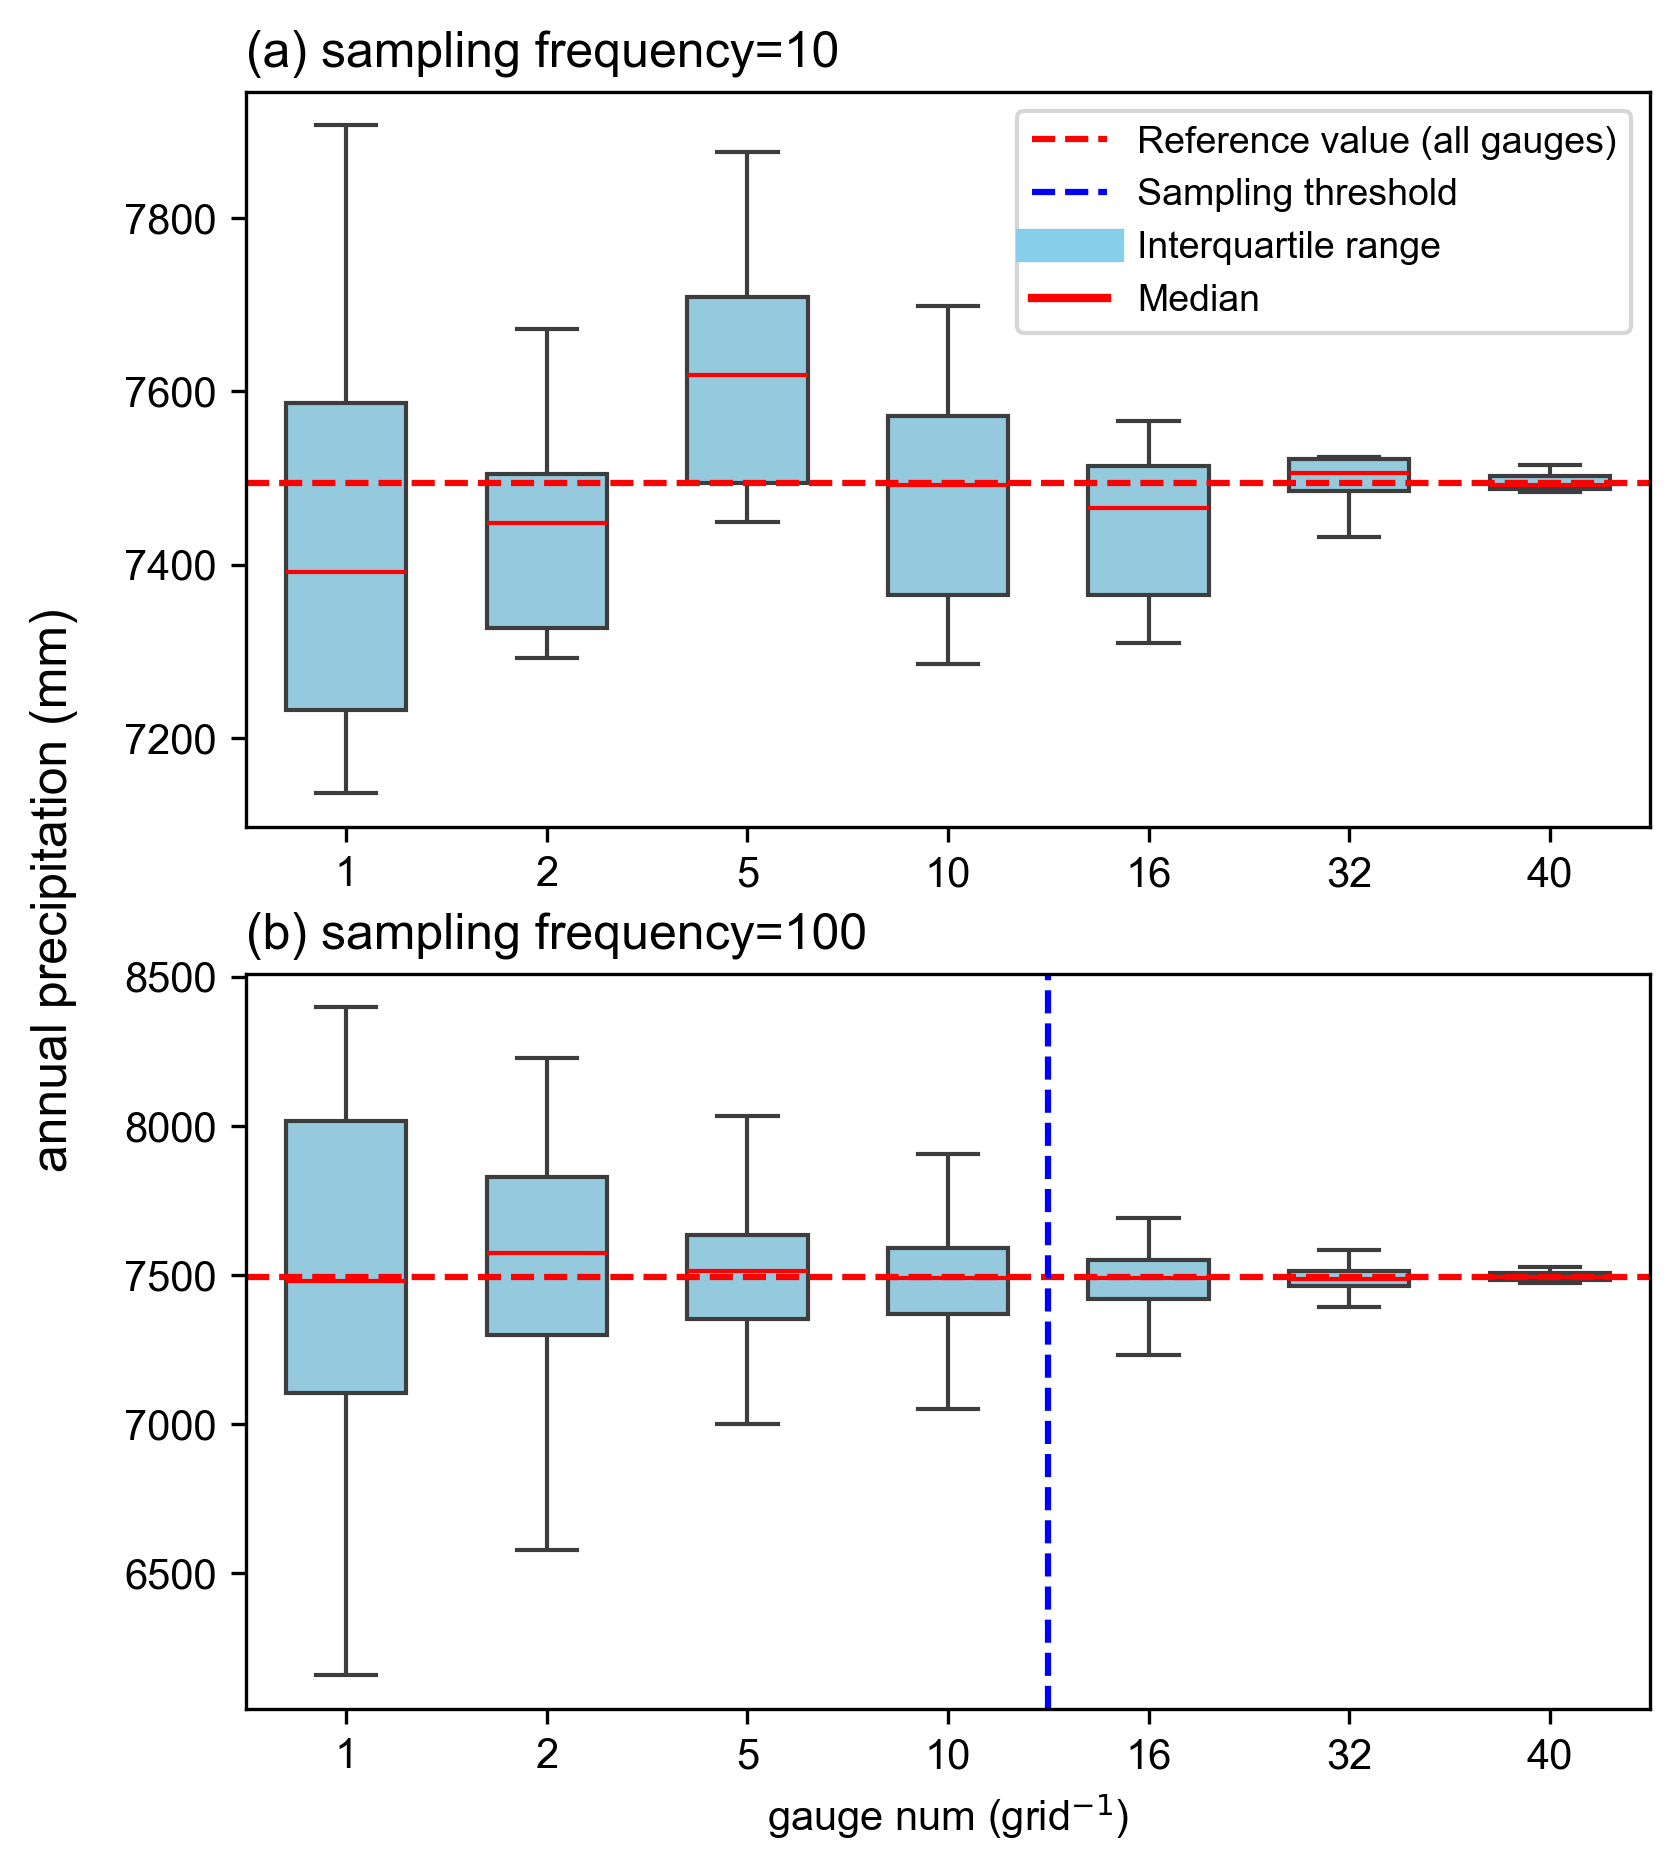

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']  # 确保优先使用 Arial
# Assuming 'rain' and 'mean_pre' are defined elsewhere
selected_indices = [1,  2 , 5,  10,  16,32,40]


# Create 3x1 subplots
fig, axes = plt.subplots(2, 1, figsize=(6, 7),dpi=300)  # 3x1 layout

# Plot each part in a separate subplot
for ax, rain, title_part in zip(axes, Rain.values(), range(2)):
    data_part=[rain[idx] for idx in selected_indices]#whis=[0.5, 99],
    sns.boxplot(data=data_part,  width=0.6, color='skyblue', ax=ax,showfliers=False,medianprops={'color': 'red'})
    # sns.violinplot(data=data_part, inner='quartile', width=1.0, color='skyblue', ax=ax, )
    # Set x-axis labels
    ax.set_xticks(np.arange(len(data_part)))
    ax.set_xticklabels(selected_indices[:len(data_part)])  # Adjust labels accordingly
    
    
    # # Add median labels
    # for i, data in enumerate(data_part):
    #     median = np.median(data)
    #     ax.text(i, median, f'{median:.2f}', horizontalalignment='center', color='k',weight='bold' )#

    # Add red horizontal line for mean_pre
    ax.axhline(y=mean_pre, color='red', linestyle='--', linewidth=1.5)

ax.set_xlabel("gauge num (grid$^{-1}$)")
axes[0].set_title(f"(a) sampling frequency=10",loc='left')
axes[1].set_title(f"(b) sampling frequency=100",loc='left')
axes[1].axvline(x=3.5, color='b', linestyle='--')
# fig.ylabel("annual precipitation(mm)")
plt.subplots_adjust(left=0.12)
fig.text(0.00, 0.5, 'annual precipitation (mm)', va='center', rotation='vertical',fontsize=12)
# Adjust layout and show the figure
# plt.tight_layout()

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='red', lw=1.5, linestyle='--', label='Reference value (all gauges)'),
    Line2D([0], [0], color='blue', lw=1.5, linestyle='--', label='Sampling threshold'),
    Line2D([0], [0], color='skyblue', lw=8, label='Interquartile range'),
    Line2D([0], [0], color='red', lw=2, label='Median')
]

# 放置图例，放在第一个子图的右上角，可以根据需要调整位置
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.show()
plt.show()
